# EDA template

**Copy this file to `eda-<yourname>.ipynb` before you start working in it.**
One notebook per person — merging two people's edits to the same `.ipynb`
means resolving conflicts in JSON with embedded outputs.

Clear outputs before committing.

## Setup

Paths come from the package, not from relative `../data/...` strings, so every
cell works no matter which directory the kernel was started in.

In [56]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from un_general_debate_analysis.preprocessing import (
    OUT_DIR,
    META_COLUMNS,
    merge_country_year,
    sentence_count_columns,
)
from un_general_debate_analysis.lexicons import LEXICONS

# speeches_features.csv is 56 columns wide
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(f"reading from {OUT_DIR}")
print(f"lexicons: {list(LEXICONS)}")

reading from /Users/b/Docs/UVA/FUDS/assignments/UN-General-Debate-Analysis/data/processed
lexicons: ['theme_trust', 'theme_transformation', 'theme_multilateralism', 'industry_innovation_infrastructure']


## Load the data

`features` is the main table: one row per speech (= one country-year), with
metadata, text statistics, VADER sentiment, and four columns per lexicon.

`terms` is long — one row per (year, lexicon, term) — and shows *which* words
drive a trend.

In [57]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
terms = pd.read_csv(OUT_DIR / "lexicon_terms_by_year.csv")

print(f"features: {features.shape[0]:,} speeches x {features.shape[1]} columns")
print(f"terms:    {terms.shape[0]:,} rows")
print(f"years:    {features['year'].min()}-{features['year'].max()}")

# Sanity check: the full corpus is ~11k speeches. Many fewer means someone ran
# the pipeline with --limit; re-run it without one.
if len(features) < 10_000:
    print(f"\nWARNING: only {len(features):,} speeches — looks like a --limit sample.")

features: 11,141 speeches x 68 columns
terms:    5,931 rows
years:    1946-2025


In [58]:
features.head()

,country_code,country,year,session,region_name,sub_region_name,speaker_name,speaker_post,speaker_role,n_sentences,n_words,n_unique_lemmas,lexical_density,mean_sentence_length,sentiment_compound_mean,share_positive_sentences,share_negative_sentences,n_positive_sentences,n_negative_sentences,theme_trust_count,theme_trust_positive_sentences,theme_trust_negative_sentences,theme_trust_sentences,theme_transformation_count,theme_transformation_positive_sentences,theme_transformation_negative_sentences,theme_transformation_sentences,theme_multilateralism_count,theme_multilateralism_positive_sentences,theme_multilateralism_negative_sentences,theme_multilateralism_sentences,industry_innovation_infrastructure_count,industry_innovation_infrastructure_positive_sentences,industry_innovation_infrastructure_negative_sentences,industry_innovation_infrastructure_sentences,i,i_sentiment,n,n_sentiment,d,d_sentiment,u,u_sentiment,s,s_sentiment,t,t_sentiment,r,r_sentiment,y,y_sentiment,_,__sentiment,o,o_sentiment,v,v_sentiment,a,a_sentiment,f,f_sentiment,c,c_sentiment,e,e_sentiment,technology_education,technology_education_sentiment,term_counts
0,ARG,Argentina,1946,1,Americas,Latin America and the Caribbean,Mr. Arce,NaN,unknown,127,3305,943,0.485023,26.023622,0.260215,0.590551,0.204724,75,26,1,1,0,1,0,0,0,0,17,6,2,13,92,39,10,59,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 91, ""charter"": 11, ""good faith"": 1, ""i..."
1,AUS,Australia,1946,1,Oceania,Australia and New Zealand,Mr. Makin,NaN,unknown,125,4475,911,0.495866,35.800000,0.392232,0.720000,0.136000,90,17,4,4,0,4,0,0,0,0,51,29,7,39,109,49,11,66,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 107, ""bridge"": 1, ""charter"": 28, ""clou..."
2,BEL,Belgium,1946,1,Europe,Western Europe,Mr. Van Langenhove,NaN,unknown,98,2479,688,0.482453,25.295918,0.229380,0.581633,0.214286,57,21,0,0,0,0,1,1,0,1,24,18,2,20,61,28,13,49,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 59, ""charter"": 15, ""commerce"": 1, ""inn..."
3,BLR,Belarus,1946,1,Europe,Eastern Europe,Mr. Kiselev,NaN,unknown,98,3011,803,0.521089,30.724490,0.233941,0.622449,0.295918,61,29,3,3,0,3,0,0,0,0,32,25,1,28,106,35,18,56,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 103, ""charter"": 15, ""confidence"": 1, ""..."
4,BOL,Bolivia (Plurinational State of),1946,1,Americas,Latin America and the Caribbean,Mr. Costa du Rels,NaN,unknown,55,1445,545,0.480969,26.272727,0.251342,0.563636,0.181818,31,10,1,1,0,1,0,0,0,0,3,2,0,3,38,14,6,23,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 38, ""charter"": 2, ""confidence"": 1, ""se..."


### The text, loaded separately

`speeches_text.csv.gz` holds the cleaned text and the lemmatised, stop-word-free
tokens of every speech. It is a few hundred MB in memory for the full corpus, so
only load it when you actually need it (TF-IDF, topic models, word clouds).

In [59]:
texts = pd.read_csv(OUT_DIR / "speeches_text.csv.gz")
texts.head()

,country_code,year,text_clean,tokens_clean
0,ARG,1946,At the resumption of the first session of the ...,resumption first argentine wish view number qu...
1,AUS,1946,The General Assembly of the United Nations is ...,meeting time hospitable city new york exercise...
2,BEL,1946,The principal organs of the United Nations hav...,principal organ functioning nearly nine month ...
3,BLR,1946,As more than a year has elapsed since the Unit...,year elapse since charter sign san francisco c...
4,BOL,1946,Coming to this platform where so many distingu...,coming platform many eloquent speaker precede ...


### `term_counts` is a JSON string

Parse it with `json.loads` (not `ast.literal_eval`) to get the per-term counts
for a single speech.

In [60]:
example = features.iloc[0]
print(f"{example['country']}, {example['year']}")
json.loads(example["term_counts"])

Argentina, 1946


{'and': 91,
 'charter': 11,
 'good faith': 1,
 'international law': 3,
 'multilateral': 1,
 'road': 1,
 'security council': 1,
 'solidarity': 1}

## Normalise before comparing

Speech length varies enormously across the corpus, and so does the number of
countries speaking each year (~50 in 1946, ~190 today). Raw counts are not
comparable across speeches or across years — always divide first.

- word counts (`<lexicon>_count`) by `n_words`
- sentence counts (`<lexicon>_sentences`) by `n_sentences`

In [118]:
rates = features[META_COLUMNS[:4]].copy()
for lexicon in LEXICONS:
    rates[f"{lexicon}_per_1k_words"] = (
        1_000 * features[f"{lexicon}_count"] / features["n_words"]
    )

rates.groupby("year")[[f"{lex}_per_1k_words" for lex in LEXICONS]].mean().tail()

,theme_trust_per_1k_words,theme_transformation_per_1k_words,theme_multilateralism_per_1k_words,industry_innovation_infrastructure_per_1k_words
year,,,,
2021,1.124144,1.990060,3.674766,45.204050
2022,1.307592,2.141185,4.391487,45.440528
2023,2.150253,2.159904,5.240887,45.933645
2024,1.612256,2.682532,5.518742,47.780410
2025,1.785045,2.573753,5.606194,47.319800


In [119]:
rates

,country_code,country,year,session,theme_trust_per_1k_words,theme_transformation_per_1k_words,theme_multilateralism_per_1k_words,industry_innovation_infrastructure_per_1k_words
0,ARG,Argentina,1946,1,0.302572,0.000000,5.143722,27.836611
1,AUS,Australia,1946,1,0.893855,0.000000,11.396648,24.357542
2,BEL,Belgium,1946,1,0.000000,0.403388,9.681323,24.606696
3,BLR,Belarus,1946,1,0.996347,0.000000,10.627698,35.204251
4,BOL,Bolivia (Plurinational State of),1946,1,0.692042,0.000000,2.076125,26.297578
...,...,...,...,...,...,...,...,...
11136,WSM,Samoa,2025,80,2.120891,2.651113,3.711559,48.780488
11137,YEM,Yemen,2025,80,3.013864,1.808318,0.602773,57.866184
11138,ZAF,South Africa,2025,80,2.267574,1.360544,12.698413,45.804989
11139,ZMB,Zambia,2025,80,0.498504,2.991027,5.483549,40.877368


In [120]:
# A first look: how much the themes are talked about over time
value_col = "industry_innovation_infrastructure_per_1k_words"

yearly = rates.groupby("year")[value_col].agg(
    mean="mean",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
)

iqr = yearly["q3"] - yearly["q1"]
lower_fence = yearly["q1"] - 1.5 * iqr
upper_fence = yearly["q3"] + 1.5 * iqr

outliers = rates.groupby("year")[value_col].apply(
    lambda s: pd.Series({
        "outlier_low": s[s < lower_fence.loc[s.name]].min(),
        "outlier_high": s[s > upper_fence.loc[s.name]].max(),
    })
).unstack()

yearly = yearly.join(outliers)


In [121]:
rates = rates.join(yearly, on ='year' )

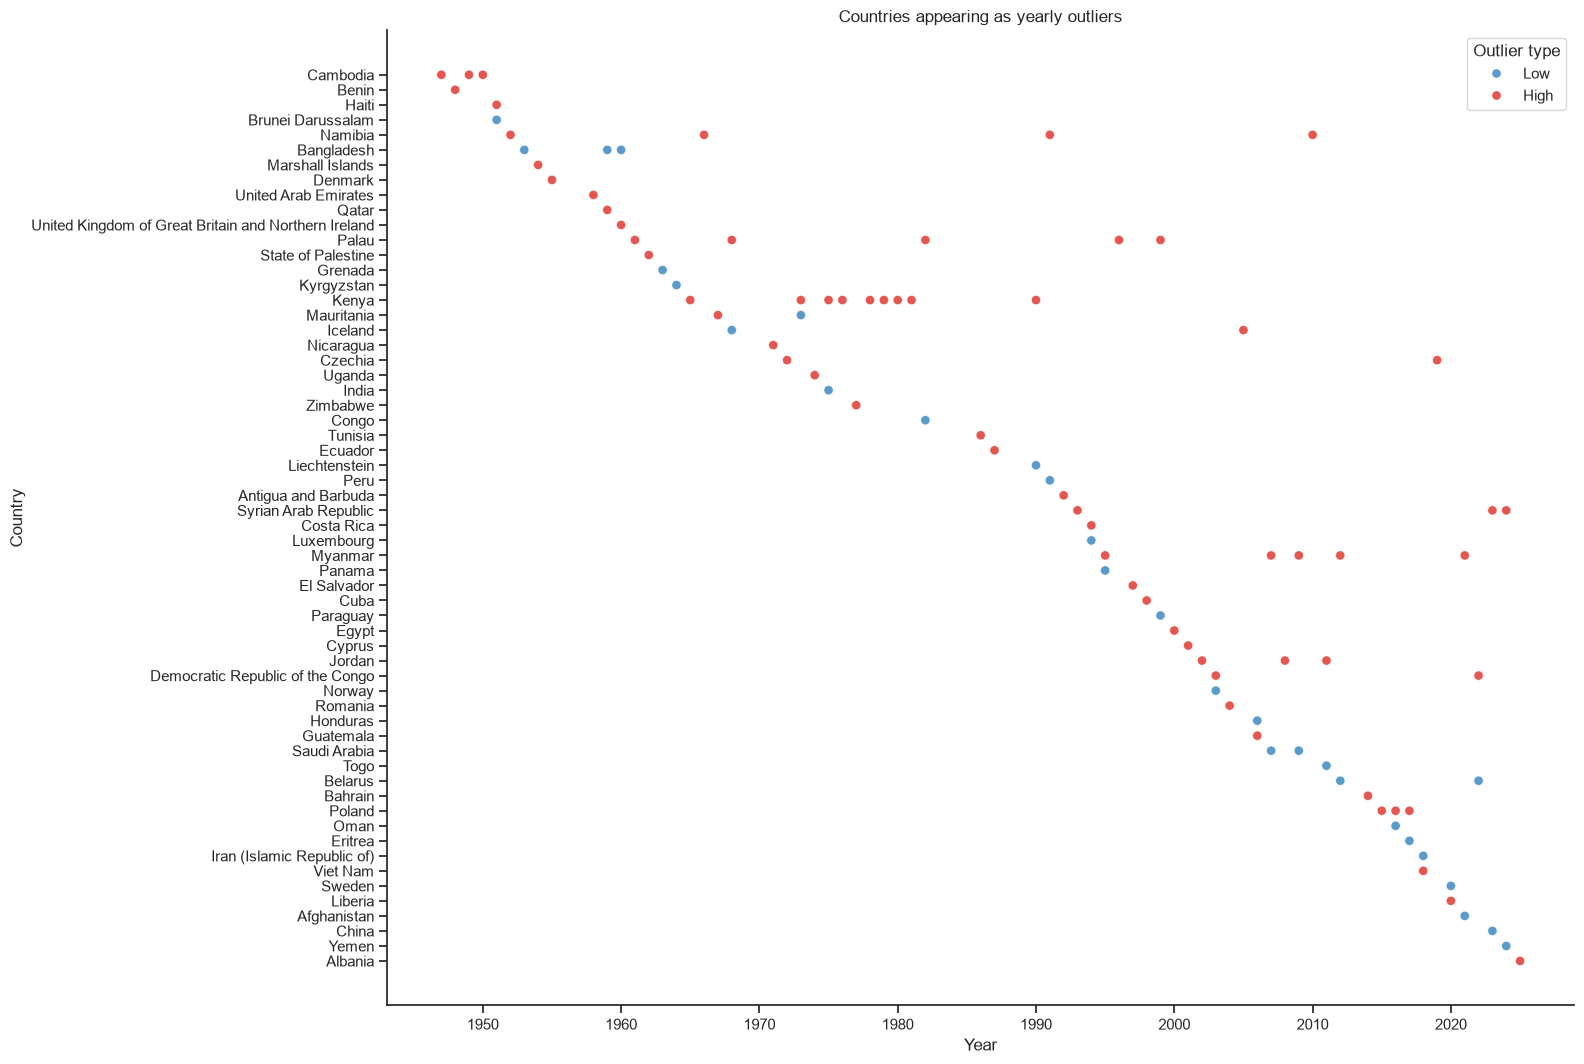

In [ ]:
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

rates['outlier_low_flag'] = rates['industry_innovation_infrastructure_per_1k_words'] <= rates['outlier_low']
rates['outlier_high_flag'] = rates['industry_innovation_infrastructure_per_1k_words'] >= rates['outlier_high']

rates_outliers = rates[(rates['outlier_low_flag'] == 1) | (rates['outlier_high_flag'] ==1)]

rates_outliers = rates_outliers[['country','year','industry_innovation_infrastructure_per_1k_words','outlier_low_flag','outlier_high_flag']]

plot_data_outliers = rates_outliers.copy()

plot_data = rates.copy()
plot_data["year_group_start"] = (plot_data["year"] // 5) * 5
plot_data["year_group"] = (
    plot_data["year_group_start"].astype(str)
    + "-"
    + (plot_data["year_group_start"] + 4).astype(str)
)

grouped = (
    plot_data.groupby(["country", "year_group_start", "year_group"], as_index=False)
    .agg(
        value=(value_col, "mean"),
        has_outlier=("outlier_low_flag", "any"),
        has_high_outlier=("outlier_high_flag", "any"),
    )
)

grouped["has_outlier"] |= grouped["has_high_outlier"]

country_order = (
    grouped.groupby("country")["value"]
    .mean()
    .sort_values()
    .index
)

vmin = grouped["value"].min()
vmax = grouped["value"].max()
vcenter = grouped["value"].median()
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

fig, ax = plt.subplots(
    figsize=(18, max(10, len(country_order) * 0.18))
)

sns.scatterplot(
    data=grouped,
    x="year_group",
    y="country",
    hue="value",
    hue_norm=norm,
    palette="coolwarm",
    marker="o",
    s=55,
    edgecolor="none",
    legend="brief",
    ax=ax,
)

outlier_points = grouped[grouped["has_outlier"]]

ax.scatter(
    outlier_points["year_group"],
    outlier_points["country"],
    marker="x",
    color="black",
    s=70,
    linewidths=1.5,
    label="Yearly outlier",
)

ax.set_yticks(range(len(country_order)))
ax.set_yticklabels(country_order)
ax.set_xlabel("Five-year period")
ax.set_ylabel("Country")
ax.set_title("Average innovation-related terms per 1,000 words")
ax.tick_params(axis="x", rotation=45)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))
sns.despine()
plt.tight_layout()
plt.show()
plot_data_outliers.loc[
    plot_data_outliers["outlier_high_flag"],
    "outlier_type",
] = "High"

# Order countries by the number of outlier years
country_order = (
    plot_data_outliers["country"]
    .value_counts()
    .sort_values()
    .index
)

fig, ax = plt.subplots(
    figsize=(16, max(8, len(country_order) * 0.18))
)

sns.scatterplot(
    data=plot_data_outliers,
    x="year",
    y="country",
    hue="outlier_type",
    hue_order=["Low", "High"],
    palette={"Low": "#3182bd", "High": "#de2d26"},
    s=45,
    alpha=0.8,
    ax=ax,
)

ax.set_yticks(range(len(country_order)))
ax.set_yticklabels(country_order)
ax.set_xlabel("Year")
ax.set_ylabel("Country")
ax.set_title("Countries appearing as yearly outliers")
ax.legend(title="Outlier type")
sns.despine()
plt.tight_layout()
plt.show()

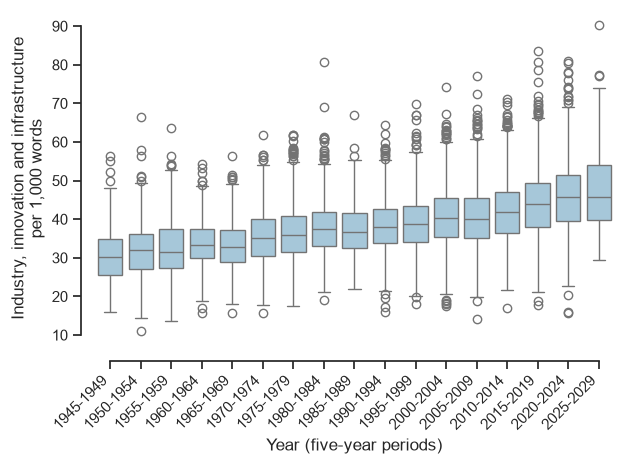

In [133]:
plot_data = rates.copy()

plot_data["year_group"] = (plot_data["year"] // 5) * 5
plot_data["year_group"] = plot_data["year_group"].astype(str) + "-" + (plot_data["year_group"] + 4).astype(str)

plt.Figure(figsize=(20,20))


sns.boxplot(x="year_group",
            y="industry_innovation_infrastructure_per_1k_words",
            data=plot_data,
            color="#9ecae1",)
sns.despine(offset=10, trim=True)

plt.xlabel("Year (five-year periods)")
plt.ylabel("Industry, innovation and infrastructure\nper 1,000 words")
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [74]:
plot_data_outliers = 

,country_code,country,year,session,theme_trust_per_1k_words,theme_transformation_per_1k_words,theme_multilateralism_per_1k_words,industry_innovation_infrastructure_per_1k_words,year_group
0,ARG,Argentina,1946,1,0.302572,0.000000,5.143722,27.836611,1945-1949
1,AUS,Australia,1946,1,0.893855,0.000000,11.396648,24.357542,1945-1949
2,BEL,Belgium,1946,1,0.000000,0.403388,9.681323,24.606696,1945-1949
3,BLR,Belarus,1946,1,0.996347,0.000000,10.627698,35.204251,1945-1949
4,BOL,Bolivia (Plurinational State of),1946,1,0.692042,0.000000,2.076125,26.297578,1945-1949
...,...,...,...,...,...,...,...,...,...
11136,WSM,Samoa,2025,80,2.120891,2.651113,3.711559,48.780488,2025-2029
11137,YEM,Yemen,2025,80,3.013864,1.808318,0.602773,57.866184,2025-2029
11138,ZAF,South Africa,2025,80,2.267574,1.360544,12.698413,45.804989,2025-2029
11139,ZMB,Zambia,2025,80,0.498504,2.991027,5.483549,40.877368,2025-2029


## Bringing in an external dataset

`merge_country_year` joins on `(country_code, year)` with ISO-3166 alpha-3 codes.
Its defaults match Our World in Data exports (`Entity`, `Code`, `Year`); pass
`country_col` / `year_col` for anything else.

Remember the corpus contains states that no longer exist (`CSK`, `DDR`, `YUG`,
`YMD`) plus `EU`, which external datasets usually lack — expect NaNs there.

In [8]:
# owid = pd.read_csv("../data/external/some-indicator.csv")
# df = merge_country_year(features, owid)
#
# happiness = pd.read_csv("../data/external/happiness.csv")
# df = merge_country_year(features, happiness, country_col="iso3", year_col="year")
#
# print(f"matched {df['<indicator>'].notna().sum():,} of {len(df):,} speeches")

In [26]:
# https://data.worldbank.org/indicator/IT.NET.USER.ZS?locations=1W&start=1990&end=2023&view=chart

,country_code,country,year,session,region_name,sub_region_name,speaker_name,speaker_post,speaker_role,n_sentences,n_words,n_unique_lemmas,lexical_density,mean_sentence_length,sentiment_compound_mean,share_positive_sentences,share_negative_sentences,n_positive_sentences,n_negative_sentences,theme_trust_count,theme_trust_positive_sentences,theme_trust_negative_sentences,theme_trust_sentences,theme_transformation_count,theme_transformation_positive_sentences,theme_transformation_negative_sentences,theme_transformation_sentences,theme_multilateralism_count,theme_multilateralism_positive_sentences,theme_multilateralism_negative_sentences,theme_multilateralism_sentences,industry_innovation_infrastructure_count,industry_innovation_infrastructure_positive_sentences,industry_innovation_infrastructure_negative_sentences,industry_innovation_infrastructure_sentences,i,i_sentiment,n,n_sentiment,d,d_sentiment,u,u_sentiment,s,s_sentiment,t,t_sentiment,r,r_sentiment,y,y_sentiment,_,__sentiment,o,o_sentiment,v,v_sentiment,a,a_sentiment,f,f_sentiment,c,c_sentiment,e,e_sentiment,technology_education,technology_education_sentiment,term_counts
0,ARG,Argentina,1946,1,Americas,Latin America and the Caribbean,Mr. Arce,NaN,unknown,127,3305,943,0.485023,26.023622,0.260215,0.590551,0.204724,75,26,1,1,0,1,0,0,0,0,17,6,2,13,92,39,10,59,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 91, ""charter"": 11, ""good faith"": 1, ""i..."
1,AUS,Australia,1946,1,Oceania,Australia and New Zealand,Mr. Makin,NaN,unknown,125,4475,911,0.495866,35.800000,0.392232,0.720000,0.136000,90,17,4,4,0,4,0,0,0,0,51,29,7,39,109,49,11,66,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 107, ""bridge"": 1, ""charter"": 28, ""clou..."
2,BEL,Belgium,1946,1,Europe,Western Europe,Mr. Van Langenhove,NaN,unknown,98,2479,688,0.482453,25.295918,0.229380,0.581633,0.214286,57,21,0,0,0,0,1,1,0,1,24,18,2,20,61,28,13,49,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 59, ""charter"": 15, ""commerce"": 1, ""inn..."
3,BLR,Belarus,1946,1,Europe,Eastern Europe,Mr. Kiselev,NaN,unknown,98,3011,803,0.521089,30.724490,0.233941,0.622449,0.295918,61,29,3,3,0,3,0,0,0,0,32,25,1,28,106,35,18,56,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 103, ""charter"": 15, ""confidence"": 1, ""..."
4,BOL,Bolivia (Plurinational State of),1946,1,Americas,Latin America and the Caribbean,Mr. Costa du Rels,NaN,unknown,55,1445,545,0.480969,26.272727,0.251342,0.563636,0.181818,31,10,1,1,0,1,0,0,0,0,3,2,0,3,38,14,6,23,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 38, ""charter"": 2, ""confidence"": 1, ""se..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11136,WSM,Samoa,2025,80,Oceania,Polynesia,Toelupe Maoiautele Poumulinuku Onesemo,Deputy Prime Minister,deputy_head_of_state_or_government,104,1886,731,0.595970,18.134615,0.228921,0.663462,0.221154,69,23,4,3,0,3,5,1,0,2,7,6,0,6,92,41,11,57,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""ai"": 1, ""and"": 88, ""bridge"": 1, ""charter"": 1..."
11137,YEM,Yemen,2025,80,Asia,Western Asia,Rashad Mohammed Al-Alimi,President of the Presidential Leadership Council,head_of_state,68,1659,538,0.521398,24.397059,0.169126,0.602941,0.250000,41,17,5,2,2,5,3,0,1,2,1,0,1,1,96,22,14,42,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,"{""and"": 94, ""credibility"": 2, ""international l..."
11138,ZAF,South Africa,2025,80,Africa,Sub-Saharan Africa,Cyril Matamela Ramaphosa,President,he

## Your analysis below

Two reminders from the brief:

- Session 80 (2025) was transcribed from interpretation audio, not official
  transcripts. Be careful reading a 2025 "trend" as real.
- `speaker_role` is `unknown` for many pre-1994 speeches; the UN records do not
  consistently give the speaker's post before then.

In [9]:
texts

,country_code,year,text_clean,tokens_clean
0,ARG,1946,At the resumption of the first session of the ...,resumption first argentine wish view number qu...
1,AUS,1946,The General Assembly of the United Nations is ...,meeting time hospitable city new york exercise...
2,BEL,1946,The principal organs of the United Nations hav...,principal organ functioning nearly nine month ...
3,BLR,1946,As more than a year has elapsed since the Unit...,year elapse since charter sign san francisco c...
4,BOL,1946,Coming to this platform where so many distingu...,coming platform many eloquent speaker precede ...
...,...,...,...,...
11136,WSM,2025,"Poumulikinuku Onesemo, Deputy Prime Minister o...",poumulikinuku onesemo deputy prime minister sa...
11137,YEM,2025,"In the name of God, Most Gracious, Most Mercif...",name god gracious merciful statement today ent...
11138,ZAF,2025,"Thank you, President of the 80th Session of th...",th un head government eight year ago establish...
11139,ZMB,2025,"Your Excellency, Madam Annalena Birbock, Presi...",annalena birbock th antonio guterres head gove...


/var/folders/d2/xd2z0dzd25906v020j08jqd00000gn/T/ipykernel_3301/2721268008.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


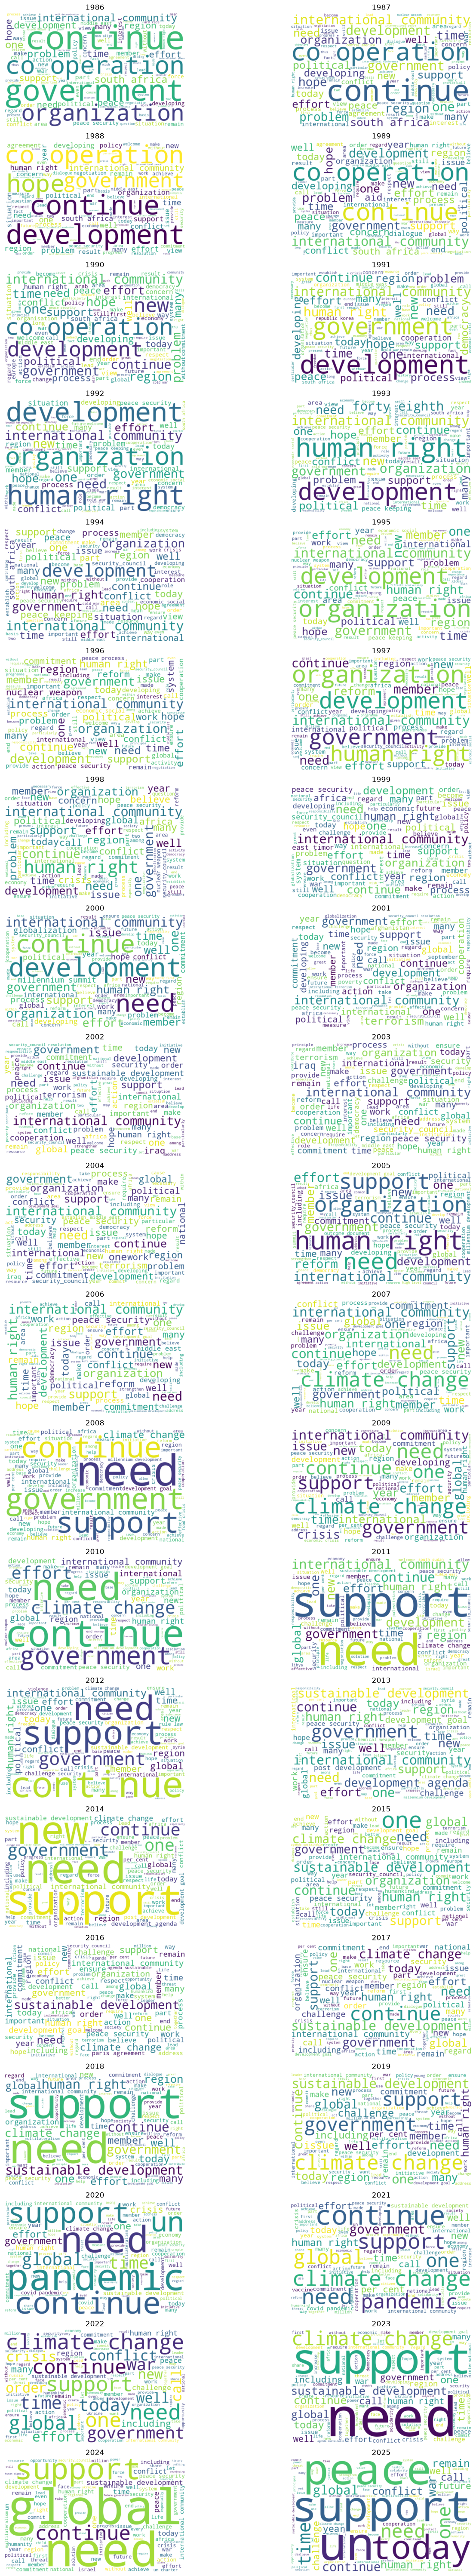

In [24]:
from wordcloud import WordCloud

last_year = texts["year"].max()
years = list(range(last_year - 39, last_year + 1))

fig, axes = plt.subplots(
    20,
    2,
    figsize=(16, 60),
    constrained_layout=True,
)
axes = axes.ravel()

for ax, year in zip(axes, years):
    tokens = texts.loc[texts["year"].eq(year), "tokens_clean"].dropna()
    text = " ".join(tokens.astype(str))

    if text.strip():
        cloud = WordCloud(
            width=800,
            height=500,
            background_color="white",
            colormap="viridis",
            max_words=100,
        ).generate(text)

        ax.imshow(cloud, interpolation="bilinear")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")

    ax.set_title(str(year))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
import wbwdi as wb

wb.wdi_set_format("polars")

df = wb.wdi_get(
  entities=["MEX", "CAN", "USA"], 
  indicators=["NY.GDP.PCAP.KD", "SP.POP.TOTL"],
  start_year=2020, 
  end_year=2024
).to_pandas()

df.head()

,entity_id,indicator_id,value,year
0,CAN,NY.GDP.PCAP.KD,42366.171094,2020
1,MEX,NY.GDP.PCAP.KD,9234.643622,2020
2,USA,NY.GDP.PCAP.KD,59533.609024,2020
3,CAN,NY.GDP.PCAP.KD,44639.238117,2021
4,MEX,NY.GDP.PCAP.KD,9728.056800,2021


In [22]:
wb.wdi_get_indicators()


indicator_id,indicator_name,source_id,source_name,source_note,source_organization,topics
str,str,i64,str,str,str,list[struct[2]]
"""1.0.HCount.1.90usd""","""Poverty Headcount ($1.90 a day…",37,"""LAC Equity Lab""","""The poverty headcount index me…","""LAC Equity Lab tabulations of …","[{11,""Poverty""}]"
"""1.0.HCount.2.5usd""","""Poverty Headcount ($2.50 a day…",37,"""LAC Equity Lab""","""The poverty headcount index me…","""LAC Equity Lab tabulations of …","[{11,""Poverty""}]"
"""1.0.HCount.Mid10to50""","""Middle Class ($10-50 a day) He…",37,"""LAC Equity Lab""","""The poverty headcount index me…","""LAC Equity Lab tabulations of …","[{11,""Poverty""}]"
"""1.0.HCount.Ofcl""","""Official Moderate Poverty Rate…",37,"""LAC Equity Lab""","""The poverty headcount index me…","""LAC Equity Lab tabulations of …","[{11,""Poverty""}]"
"""1.0.HCount.Poor4uds""","""Poverty Headcount ($4 a day)""",37,"""LAC Equity Lab""","""The poverty headcount index me…","""LAC Equity Lab tabulations of …","[{11,""Poverty""}]"
…,…,…,…,…,…,…
"""ytil_some_dfcl_all""","""Youth idle rate (% of persons …",92,"""Disability Data Hub (DDH)""",null,null,"[{null,null}]"
"""ytil_some_dfcl_fem""","""Youth idle rate (% of female p…",92,"""Disability Data Hub (DDH)""",null,null,"[{null,null}]"
"""ytil_some_dfcl_male""","""Youth idle rate (% of male per…",92,"""Disability Data Hub (DDH)""",null,null,"[{null,null}]"


In [46]:
indicators=wb.wdi_get_indicators()

wb.wdi_search(
  indicators,
  keywords=["Science"],
  columns=["indicator_name"]
)

indicator_id,indicator_name,source_id,source_name,source_note,source_organization,topics
str,str,i64,str,str,str,list[struct[2]]
"""2.0.cov.Scie.pl_2.all""","""Coverage: Science Proficiency …",37,"""LAC Equity Lab""","""The coverage rate is the child…","""LAC Equity Lab tabulations usi…","[{11,""Poverty""}]"
"""2.0.cov.Scie.pl_2.prv""","""Coverage: Science Proficiency …",37,"""LAC Equity Lab""","""The coverage rate is the child…","""LAC Equity Lab tabulations usi…","[{11,""Poverty""}]"
"""2.0.cov.Scie.pl_2.pub""","""Coverage: Science Proficiency …",37,"""LAC Equity Lab""","""The coverage rate is the child…","""LAC Equity Lab tabulations usi…","[{11,""Poverty""}]"
"""2.0.cov.Scie.pl_3.all""","""Coverage: Science Proficiency …",37,"""LAC Equity Lab""","""The coverage rate is the child…","""LAC Equity Lab tabulations usi…","[{11,""Poverty""}]"
"""2.0.cov.Scie.pl_3.prv""","""Coverage: Science Proficiency …",37,"""LAC Equity Lab""","""The coverage rate is the child…","""LAC Equity Lab tabulations usi…","[{11,""Poverty""}]"
…,…,…,…,…,…,…
"""UIS.ESG.LOWERSEC.NCOG.ENJO.GPI""","""Percentage of students in lowe…",12,"""Education Statistics""","""The Adjusted Gender Parity Ind…","""UNESCO Institute for Statistic…","[{null,null}]"
"""UIS.ESG.LOWERSEC.NCOG.ENJO.M""","""Percentage of students in lowe…",12,"""Education Statistics""","""Percentage of students in lowe…","""UNESCO Institute for Statistic…","[{null,null}]"
"""UIS.FGP.5T8.FNON500600700""","""Female share of graduates in o…",14,"""Gender Statistics""","""Female share of graduates in t…","""UNESCO Institute for Statistic…","[{4,""Education""}]"


In [44]:

topics = (
    indicators
    .select("topics")
    .explode("topics")
    .unnest("topics")
)

topic_names = (
    topics
    .select(topics.columns[-1])
    .drop_nulls()
    .unique()
    .sort(topics.columns[-1])
)

print(topic_names)


shape: (21, 1)
┌─────────────────────────────────┐
│ topic_name                      │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ Agriculture & Rural Developmen… │
│ Aid Effectiveness               │
│ Climate Change                  │
│ Economy & Growth                │
│ Education                       │
│ …                               │
│ Science & Technology            │
│ Social Development              │
│ Social Protection & Labor       │
│ Trade                           │
│ Urban Development               │
└─────────────────────────────────┘


/var/folders/d2/xd2z0dzd25906v020j08jqd00000gn/T/ipykernel_3301/231146525.py:4: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("topics")
